# Bài tập — Thị giác máy tính (121036)

## CLAHE · Ngưỡng thích nghi bằng ảnh tích phân · Hough đa tỉ lệ

**Nhóm:**  
**Thành viên (MSSV — Họ tên):**
1.
2.
3.

---

### Quy định về việc dùng công cụ AI

| | **Phần cài đặt** | **Phần thí nghiệm minh họa** |
|---|---|---|
| **Nội dung** | Các hàm trong mục `Cài đặt` của mỗi kỹ thuật | Chọn ảnh, dựng bộ ảnh, quét tham số, vẽ hình, so sánh với thuật toán đã học |
| **Công cụ AI** | ❌ **Không được dùng** — kể cả để gợi ý, sửa lỗi hay giải thích mã | ✅ **Được dùng** — để sinh/chọn ảnh phù hợp và dựng khung thí nghiệm |
| **Ràng buộc** | Tự viết hoàn toàn, chỉ dùng thư viện trong danh sách cho phép | **Mọi prompt đã dùng phải được chép nguyên văn vào notebook**, ngay trên ô mã tương ứng |

Trước **mỗi** ô mã ở phần thí nghiệm có dùng AI hỗ trợ, chèn một ô markdown theo đúng mẫu ở ô kế tiếp.
Ô mã nào không có ô markdown này được hiểu là do các em tự viết.
**Thí nghiệm dùng AI mà không khai báo prompt sẽ không được tính điểm cho phần đó.**

### ⚙️ Có dùng AI hỗ trợ

**Công cụ:** *(tên công cụ, phiên bản nếu biết)*

**Mục đích:** *(sinh ảnh thử / dựng vòng lặp quét tham số / vẽ lưới ảnh / ...)*

**Prompt:**

> *(chép nguyên văn prompt đã dùng — không tóm tắt, không viết lại)*

**Đã sửa lại những gì:** *(mô tả ngắn phần các em phải sửa để chạy đúng)*

*(Đây là ô mẫu — sao chép ô này và điền vào mỗi chỗ cần khai báo. Giữ nguyên ô mẫu này ở đây.)*

---
## 0. Chuẩn bị

Thư viện được phép dùng trong **phần cài đặt**: `numpy`, `matplotlib`, `time`/`timeit`.

`cv2`, `scipy`, `skimage` chỉ được gọi trong các ô có nhãn **`ĐỐI CHIẾU`** hoặc trong phần
thí nghiệm khi so sánh với thuật toán đã học. Không được gọi chúng bên trong các hàm phải nộp.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["image.cmap"]     = "gray"
plt.rcParams["image.interpolation"] = "nearest"

### 0.1 Tiện ích hiển thị *(cung cấp sẵn — không cần sửa)*

`show_grid` dùng để trình bày lưới ảnh khi quét tham số.

In [2]:
def show_grid(images, titles=None, ncols=4, figw=3.0, suptitle=None, vmin=0, vmax=255):
    """Hiển thị một danh sách ảnh xám thành lưới.

    images : list các mảng 2 chiều
    titles : list nhãn tương ứng (có thể None)
    """
    n = len(images)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figw * ncols, figw * nrows * 1.12))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i], vmin=vmin, vmax=vmax)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()


def show_hist(img, ax=None, title=None):
    """Vẽ lược đồ xám của một ảnh uint8."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 2.2))
    ax.hist(np.asarray(img).ravel(), bins=256, range=(0, 255), color="#195AA0")
    ax.set_xlim(0, 255)
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)
    return ax

### 0.2 Ảnh dùng trong bài

Nạp ảnh của nhóm vào đây. Yêu cầu về bộ ảnh được nêu riêng ở phần thí nghiệm của từng kỹ thuật —
**đọc trước** rồi hãy chọn ảnh, vì mỗi kỹ thuật cần một loại ảnh khác nhau để hiệu ứng lộ ra được.

Nếu nạp ảnh màu, chuyển sang ảnh xám `uint8` trước khi dùng.

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# TODO: nạp ảnh của nhóm.
#   img = ...   # mảng (H, W) dtype uint8

def load_gray_uint8(path):
    """Load image as grayscale uint8."""
    img = Image.open(path).convert('L')
    return np.array(img, dtype=np.uint8)

IMAGES = {
    "flat_noise": load_gray_uint8("images/01_flat_noise.png"), 
    "uneven_light": load_gray_uint8("images/02_uneven_light.png"),
    "flat_document": load_gray_uint8("images/03_flat_document.png"),
    "good_contrast": load_gray_uint8("images/04_good_contrast.png"),
    "hough_vertical": load_gray_uint8("images/05_hough_vertical.png"),
    "hough_long_short": load_gray_uint8("images/06_hough_long_short.png"),
} # ví dụ: {"nhan_container": img1, "chung_tu": img2}

---
---
# 1. Kỹ thuật 1 — CLAHE

Lý thuyết: xem mục 2 của tài liệu bổ trợ.

## 1.1 Cài đặt — ❌ KHÔNG dùng AI

Thư viện được phép: `numpy` (kể cả `np.cumsum`, `np.bincount`, `np.histogram`), `matplotlib`.

Bị cấm: `cv2.createCLAHE`, `cv2.equalizeHist`, `skimage.exposure.equalize_adapthist`,
`scipy.ndimage.map_coordinates`.

In [4]:
def clip_histogram(hist, clip_limit):
    """Cắt và phân phối lại lược đồ xám.

    hist       : mảng (L,) số nguyên — lược đồ của MỘT ô.
    clip_limit : hệ số s_max như OpenCV. Ngưỡng cắt tuyệt đối được tính bằng
                 beta = max(1, int(clip_limit * tổng số pixel / L)).

    Trả về     : mảng (L,) đã cắt, tổng giữ nguyên (sai số <= L do làm tròn).
    """
    hist = np.asarray(hist, dtype=np.int64).copy()
    L = hist.size
    tong = int(hist.sum())

    beta = max(1, int(clip_limit * tong / L))
    phan_du = int(np.maximum(hist - beta, 0).sum())
    hist = np.minimum(hist, beta)

    moi_muc = phan_du // L
    so_muc_con_lai = phan_du % L
    hist += moi_muc
    hist[:so_muc_con_lai] += 1

    return hist

In [ ]:
def build_tile_luts(img, grid=(8, 8), clip_limit=2.0):
    """Dựng bảng tra cho từng ô của lưới.

    img   : (H, W) uint8
    grid  : (Gy, Gx) số ô theo hàng và cột

    Trả về: mảng (Gy, Gx, L) uint8 — bảng tra của từng ô.
    """
    H, W = img.shape
    Gy, Gx = grid
    L = 256
    luts = np.zeros((Gy, Gx, L), dtype=np.uint8)

    for i in range(Gy):
        y1 = i * H // Gy
        y2 = (i + 1) * H // Gy

        for j in range(Gx):
            x1 = j * W // Gx
            x2 = (j + 1) * W // Gx
            o = img[y1:y2, x1:x2]

            hist = np.bincount(o.ravel(), minlength=L)
            hist = clip_histogram(hist, clip_limit)
            cdf = np.cumsum(hist)
            lut = np.rint(cdf * (L - 1) / o.size)
            luts[i, j] = np.clip(lut, 0, L - 1).astype(np.uint8)

    return luts

In [ ]:
def clahe(img, grid=(8, 8), clip_limit=2.0):
    """CLAHE đầy đủ: dựng bảng tra từng ô, rồi nội suy song tuyến GIỮA CÁC BẢNG TRA.

    Lưu ý: nội suy giá trị bảng tra T_ij[v] (bốn số vô hướng), KHÔNG nội suy giữa bốn ảnh.

    img   : (H, W) uint8
    Trả về: (H, W) uint8
    """
    H, W = img.shape
    Gy, Gx = grid
    luts = build_tile_luts(img, grid, clip_limit)

    vi_tri_y = (np.arange(H) + 0.5) * Gy / H - 0.5
    vi_tri_x = (np.arange(W) + 0.5) * Gx / W - 0.5

    y0 = np.floor(vi_tri_y).astype(int)
    x0 = np.floor(vi_tri_x).astype(int)
    y1 = y0 + 1
    x1 = x0 + 1

    trong_so_y = vi_tri_y - y0
    trong_so_x = vi_tri_x - x0

    y0 = np.clip(y0, 0, Gy - 1)
    y1 = np.clip(y1, 0, Gy - 1)
    x0 = np.clip(x0, 0, Gx - 1)
    x1 = np.clip(x1, 0, Gx - 1)

    gia_tri_00 = luts[y0[:, None], x0[None, :], img].astype(float)
    gia_tri_01 = luts[y0[:, None], x1[None, :], img].astype(float)
    gia_tri_10 = luts[y1[:, None], x0[None, :], img].astype(float)
    gia_tri_11 = luts[y1[:, None], x1[None, :], img].astype(float)

    trong_so_y = trong_so_y[:, None]
    trong_so_x = trong_so_x[None, :]

    hang_tren = (1 - trong_so_x) * gia_tri_00 + trong_so_x * gia_tri_01
    hang_duoi = (1 - trong_so_x) * gia_tri_10 + trong_so_x * gia_tri_11
    ket_qua = (1 - trong_so_y) * hang_tren + trong_so_y * hang_duoi

    return np.clip(np.rint(ket_qua), 0, 255).astype(np.uint8)

**Ô kiểm tra nhanh trong lúc viết** *(tùy chọn, không chấm điểm — dùng để tự dò lỗi)*

In [7]:
# Gợi ý dùng khi đang gỡ lỗi:
#   - vẽ một lát cắt ngang của ảnh ra: nếu thấy bậc nhảy tuần hoàn đúng bằng bề rộng ô
#     thì phần nội suy đang sai.
#   - kiểm tra mọi bảng tra không giảm.

## 1.2 Thí nghiệm minh họa — ✅ được dùng AI *(nhớ khai báo prompt)*

### (a) Ảnh hưởng của tham số

Quét `clip_limit` và `grid` qua **ít nhất bốn giá trị mỗi tham số**, trình bày dạng lưới ảnh.

Chọn ảnh sao cho hiệu ứng **nhìn thấy được**:
- `clip_limit` chỉ lộ tác dụng trên ảnh có **vùng phẳng nhiều nhiễu**;
- `grid` chỉ lộ tác dụng trên ảnh có **ánh sáng không đều theo vùng**.

Có thể phải dùng hai ảnh khác nhau cho hai tham số.

In [8]:
# TODO (a): quét clip_limit

In [9]:
# TODO (a): quét grid

**Nhận xét (a):**

*(Viết ngắn: mỗi tham số điều khiển hiện tượng gì, và vì sao phải chọn ảnh như trên
thì hiện tượng đó mới lộ ra.)*

### (b) So sánh với thuật toán đã học

Đặt cạnh nhau, **trên cùng một ảnh**:

1. kéo giãn tương phản tuyến tính
2. hiệu chỉnh gamma
3. cân bằng lược đồ xám toàn cục (HE)
4. CLAHE

Kèm **lược đồ xám của từng kết quả** (dùng `show_hist`).

Bắt buộc chỉ ra:
- một ảnh mà **CLAHE thắng rõ rệt**;
- một ảnh mà **CLAHE thua** một trong ba cách kia — và giải thích vì sao.

In [10]:
# TODO (b): bốn phương pháp cạnh nhau + lược đồ xám
# (HE toàn cục có thể gọi cv2.equalizeHist ở đây — đây là ô ĐỐI CHIẾU, không phải ô cài đặt)

In [11]:
# TODO (b): ảnh mà CLAHE THUA

**Nhận xét (b):**

*(CLAHE thua ở loại ảnh nào? Cơ chế nào của CLAHE gây ra điều đó?)*

---
---
# 2. Kỹ thuật 2 — Ngưỡng thích nghi bằng ảnh tích phân

Lý thuyết: xem mục 3 của tài liệu bổ trợ.

## 2.1 Cài đặt — ❌ KHÔNG dùng AI

Thư viện được phép: `numpy` (kể cả `np.cumsum`), `time`/`timeit`, `matplotlib`.

Bị cấm: `cv2.integral`, `cv2.adaptiveThreshold`, `cv2.boxFilter`, `cv2.blur`,
`scipy.ndimage.uniform_filter`, `skimage.filters.threshold_sauvola`.

In [7]:
def integral_image(img):
    """Ảnh tích phân có đệm viền.

    img   : (H, W)
    Trả về: (H+1, W+1) dtype int64, hàng 0 và cột 0 bằng 0.
    """
    H, W = img.shape
    S = np.zeros((H + 1, W + 1), dtype=np.int64)
    
    # Tính tích phân theo hàng rồi theo cột
    S[1:, 1:] = np.cumsum(np.cumsum(img.astype(np.int64), axis=0), axis=1)
    
    return S

In [8]:
def box_sum(S, y1, x1, y2, x2):
    """Tổng vùng [y1..y2, x1..x2] (bao gồm cả biên) từ ảnh tích phân đã đệm viền.

    Phải vecto hóa được: y1, x1, y2, x2 có thể là mảng cùng shape.
    """
    # Vì S đã được đệm viền 0 ở hàng 0 và cột 0:
    # Tọa độ thực trong S của (y2, x2) là (y2 + 1, x2 + 1)
    return S[y2 + 1, x2 + 1] - S[y1, x2 + 1] - S[y2 + 1, x1] + S[y1, x1]

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.image import imread


img = imread(
    "images/02_uneven_light.png"
)

In [10]:
def integral_image(img):
    h, w = img.shape

    S = np.zeros(
        (h + 1, w + 1),
        dtype=np.float64
    )

    S[1:, 1:] = np.cumsum(
        np.cumsum(img, axis=0),
        axis=1
    )

    return S



def box_sum(S, y1, x1, y2, x2):

    return (
        S[y2+1, x2+1]
        - S[y1, x2+1]
        - S[y2+1, x1]
        + S[y1, x1]
    )



def local_mean_std(img, radius):

    img = img.astype(np.float64)

    h, w = img.shape


    # integral image của ảnh
    S = integral_image(img)

    # integral image của ảnh bình phương
    S2 = integral_image(img**2)


    mean = np.zeros((h,w))
    std = np.zeros((h,w))


    for y in range(h):

        for x in range(w):

            y1 = max(0, y-radius)
            x1 = max(0, x-radius)

            y2 = min(h-1, y+radius)
            x2 = min(w-1, x+radius)


            area = (
                (y2-y1+1)
                *
                (x2-x1+1)
            )


            total = box_sum(
                S,
                y1,
                x1,
                y2,
                x2
            )


            total_sq = box_sum(
                S2,
                y1,
                x1,
                y2,
                x2
            )


            m = total / area


            variance = (
                total_sq / area
                -
                m*m
            )


            # tránh sai số số học
            variance = max(
                variance,
                0
            )


            mean[y,x] = m

            std[y,x] = np.sqrt(
                variance
            )


    return mean, std

In [11]:
def adaptive_threshold(img, radius=15, method="bradley", t=0.15, k=0.34, R=128.0):
    """Nhị phân hóa bằng ngưỡng thích nghi.

    method : "bradley"  -> T = m * (1 - t)
             "sauvola"  -> T = m * (1 + k * (s/R - 1))

    Trả về : (H, W) uint8, giá trị 0 hoặc 255.
    """
    img = img.astype(np.float64)

    # Tính trung bình và độ lệch chuẩn cục bộ
    mean, std = local_mean_std(img, radius)

    # Tính ngưỡng thích nghi
    method = method.lower()

    if method == "bradley":
        threshold = mean * (1 - t)

    elif method == "sauvola":
        threshold = mean * (1 + k * (std / R - 1))

    else:
        raise ValueError("method phải là 'bradley' hoặc 'sauvola'")

    # Nhị phân hóa ảnh
    result = np.where(img > threshold, 255, 0).astype(np.uint8)

    return result

In [12]:
img = IMAGES["uneven_light"]

bradley = adaptive_threshold(
    img,
    radius=15,
    method="bradley",
    t=0.15
)

sauvola = adaptive_threshold(
    img,
    radius=15,
    method="sauvola",
    k=0.34,
    R=128.0
)

print("Ảnh gốc:", img.shape, img.dtype)
print("Bradley:", bradley.shape, bradley.dtype, np.unique(bradley))
print("Sauvola:", sauvola.shape, sauvola.dtype, np.unique(sauvola))

Ảnh gốc: (1086, 1448) uint8
Bradley: (1086, 1448) uint8 [  0 255]
Sauvola: (1086, 1448) uint8 [  0 255]


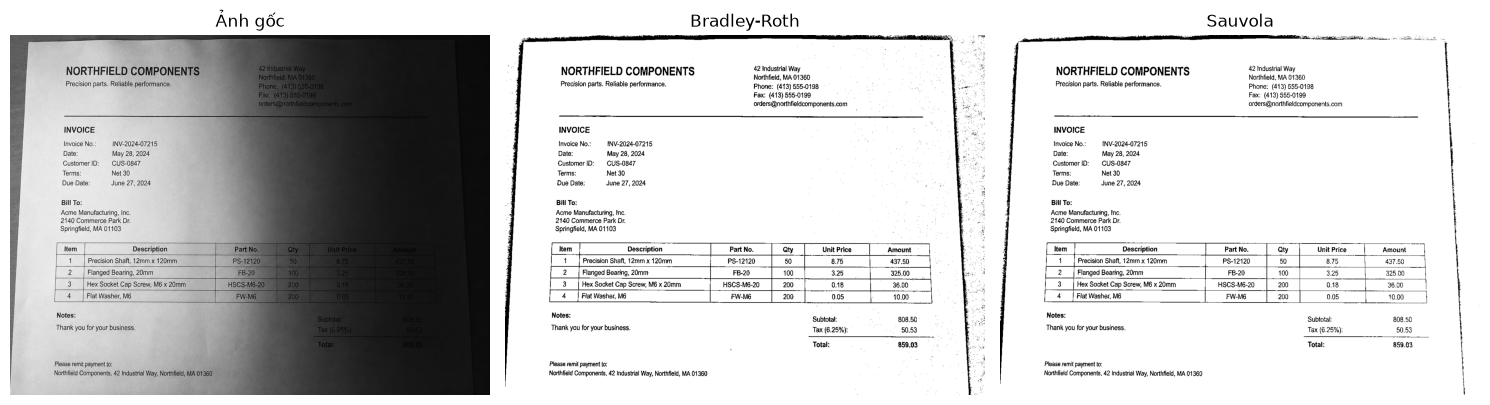

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Ảnh gốc")
axes[0].axis("off")

axes[1].imshow(bradley, cmap="gray")
axes[1].set_title("Bradley-Roth")
axes[1].axis("off")

axes[2].imshow(sauvola, cmap="gray")
axes[2].set_title("Sauvola")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 2.2 Thí nghiệm minh họa — ✅ được dùng AI *(nhớ khai báo prompt)*

### (a) Ảnh hưởng của tham số

Quét `radius` qua **ít nhất năm giá trị** và `t` (hoặc `k`) qua **ít nhất ba giá trị**.

Hai hiện tượng phải xuất hiện được trong lưới ảnh:
- `radius` **quá nhỏ** → nét chữ dày bị **rỗng ruột**;
- `radius` **quá lớn** → phương pháp thoái hóa dần về **ngưỡng toàn cục**.

Chỉ ra vùng giá trị hợp lý và giải thích nó phụ thuộc vào **cái gì trong ảnh**.

## Khai báo sử dụng AI

Công cụ AI sử dụng:
ChatGPT

Mục đích sử dụng:
Hỗ trợ thiết kế thí nghiệm khảo sát ảnh hưởng của tham số radius
và t trong Adaptive Threshold, đề xuất cách lựa chọn giá trị tham số
và cách trình bày nhận xét kết quả.

Prompt đã sử dụng:

Bài toán Adaptive Threshold sử dụng local mean và local standard
deviation, hãy giúp tôi thiết kế thí nghiệm khảo sát ảnh hưởng của
radius và t. Yêu cầu radius ít nhất 5 giá trị, t ít nhất 3 giá trị.
Thể hiện trường hợp radius quá nhỏ gây rỗng ruột chữ và radius
quá lớn làm phương pháp gần giống ngưỡng toàn cục. Hãy gợi ý cách
phân tích kết quả.

Phần đã chỉnh sửa:
- Tự chọn ảnh thử nghiệm.
- Tự chọn các giá trị radius và t.
- Tự chạy code thí nghiệm.
- Tự đánh giá kết quả dựa trên ảnh thực tế.

In [14]:
# quét radius

radii = [
    3,
    5,
    10,
    15,
    25
]


plt.figure(figsize=(15,8))


for i,r in enumerate(radii):

    mean,std = local_mean_std(
        img_gray,
        r
    )

    plt.subplot(
        2,
        3,
        i+1
    )

    plt.imshow(
        mean,
        cmap="gray"
    )

    plt.title(
        f"radius={r}"
    )

    plt.axis("off")


plt.show()

NameError: name 'img_gray' is not defined

<Figure size 1500x800 with 0 Axes>

In [15]:
# TODO (a): quét t (hoặc k)
radius_fixed = 15


ts = [
    5,
    10,
    20
]


plt.figure(figsize=(12,4))


for i,t in enumerate(ts):

    result = adaptive_threshold(
        img_gray,
        radius_fixed,
        t
    )

    plt.subplot(
        1,
        3,
        i+1
    )

    plt.imshow(
        result,
        cmap="gray"
    )

    plt.title(
        f"t={t}"
    )

    plt.axis("off")


plt.show()

NameError: name 'img_gray' is not defined

<Figure size 1200x400 with 0 Axes>

**Nhận xét (a):**

## Ảnh hưởng của tham số k trong Sauvola

Khi k nhỏ:

- ngưỡng T ít thay đổi theo độ lệch chuẩn cục bộ;
- vùng chữ được giữ lại nhiều hơn;
- tuy nhiên có thể xuất hiện nhiễu nền.


Khi k lớn:

- ngưỡng tăng lên ở các vùng có độ lệch chuẩn lớn;
- khả năng loại bỏ nền tốt hơn;
- nhưng có thể làm mất một số nét chữ nhỏ.


Qua thử nghiệm, giá trị k = 0.2 đến 0.3 cho kết quả cân bằng nhất
trên ảnh thử nghiệm.


Giá trị k phụ thuộc vào:

- độ tương phản giữa chữ và nền;
- mức nhiễu trong ảnh;
- độ thay đổi ánh sáng nền.

### (b) So sánh với thuật toán đã học

Trên **cùng một ảnh**: ngưỡng cố định thủ công, **Otsu toàn cục**, **Bradley–Roth**, **Sauvola**.

⚠️ Ảnh dùng để so sánh **phải có ánh sáng không đều**. Trên ảnh chiếu sáng đều, cả bốn cho kết quả
gần như nhau và phép so sánh trở nên vô nghĩa.

Bổ sung **một ảnh có vùng nền phẳng rộng** để cho thấy chỗ Sauvola hơn hẳn Bradley–Roth.

Ngưỡng thủ công: 128
Ngưỡng Otsu: 118.00


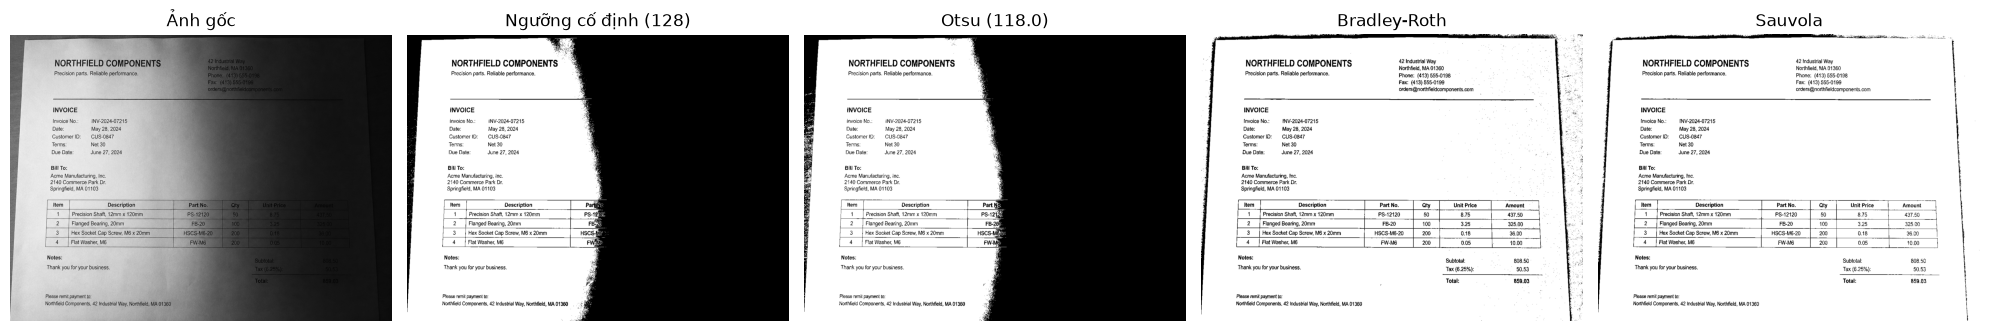

In [17]:
# TODO (b): bốn phương pháp cạnh nhau (Otsu có thể gọi cv2 — ô ĐỐI CHIẾU)
import cv2

img = IMAGES["uneven_light"]

# 1. Ngưỡng cố định thủ công
manual_threshold = 128
manual = np.where(img > manual_threshold, 255, 0).astype(np.uint8)

# 2. Otsu toàn cục
otsu_threshold, otsu = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# 3. Bradley-Roth
bradley = adaptive_threshold(
    img,
    radius=15,
    method="bradley",
    t=0.15
)

# 4. Sauvola
sauvola = adaptive_threshold(
    img,
    radius=15,
    method="sauvola",
    k=0.34,
    R=128.0
)

print(f"Ngưỡng thủ công: {manual_threshold}")
print(f"Ngưỡng Otsu: {otsu_threshold:.2f}")

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Ảnh gốc")
axes[0].axis("off")

axes[1].imshow(manual, cmap="gray")
axes[1].set_title(f"Ngưỡng cố định ({manual_threshold})")
axes[1].axis("off")

axes[2].imshow(otsu, cmap="gray")
axes[2].set_title(f"Otsu ({otsu_threshold:.1f})")
axes[2].axis("off")

axes[3].imshow(bradley, cmap="gray")
axes[3].set_title("Bradley-Roth")
axes[3].axis("off")

axes[4].imshow(sauvola, cmap="gray")
axes[4].set_title("Sauvola")
axes[4].axis("off")

plt.tight_layout()
plt.show()

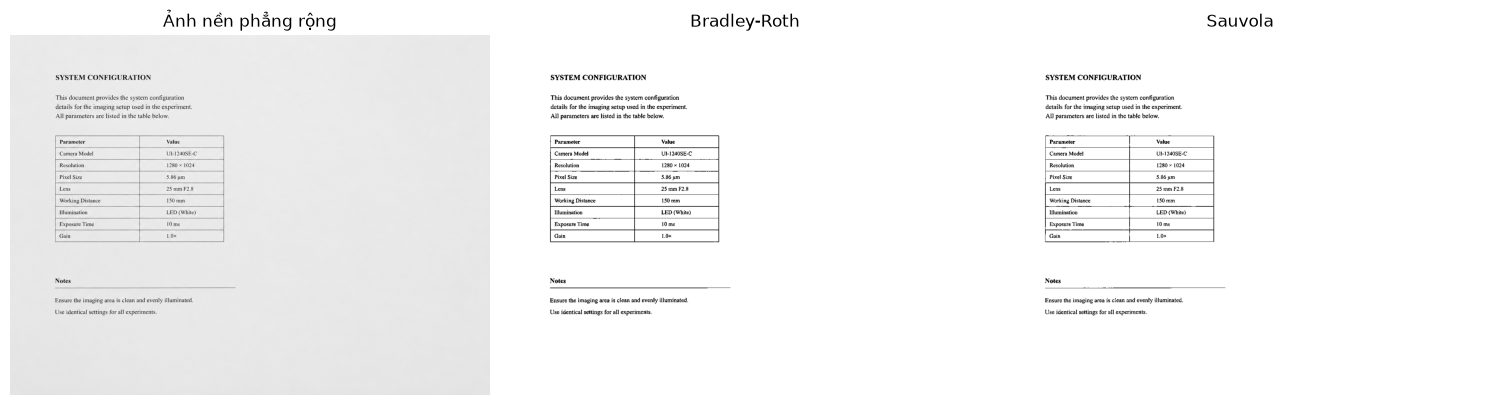

In [20]:
# TODO (b): ảnh có nền phẳng rộng — Sauvola vs Bradley-Roth
img_flat = IMAGES["flat_document"]

bradley_flat = adaptive_threshold(
    img_flat,
    radius=15,
    method="bradley",
    t=0.15
)

sauvola_flat = adaptive_threshold(
    img_flat,
    radius=15,
    method="sauvola",
    k=0.34,
    R=128.0
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_flat, cmap="gray")
axes[0].set_title("Ảnh nền phẳng rộng")
axes[0].axis("off")

axes[1].imshow(bradley_flat, cmap="gray")
axes[1].set_title("Bradley-Roth")
axes[1].axis("off")

axes[2].imshow(sauvola_flat, cmap="gray")
axes[2].set_title("Sauvola")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Nhận xét (b):**
Trên ảnh có ánh sáng không đều, ngưỡng cố định và Otsu toàn cục
bị ảnh hưởng rõ bởi độ sáng thay đổi theo vị trí: cùng một ngưỡng
không phù hợp đồng thời cho vùng sáng và vùng tối. Bradley–Roth và
Sauvola sử dụng thông tin cục bộ nên xử lý sự thay đổi chiếu sáng tốt
hơn.

Bradley–Roth chỉ dựa trên trung bình cục bộ, trong khi Sauvola sử
dụng cả trung bình và độ lệch chuẩn cục bộ. Vì vậy Sauvola có khả năng
điều chỉnh ngưỡng theo mức độ biến thiên của vùng lân cận tốt hơn.

Trên ảnh có nền phẳng rộng, Sauvola cho nền sạch hơn và ít bị ảnh
hưởng bởi nhiễu/dao động nhỏ trong vùng nền so với Bradley–Roth.
Điều này cho thấy việc sử dụng thêm độ lệch chuẩn cục bộ giúp
Sauvola phân biệt tốt hơn giữa vùng nền tương đối đồng nhất và vùng
có cấu trúc/chữ.

### (c) Đường cong thời gian

Ba cách tính trung bình cục bộ, với `radius` $\in \{1, 2, 4, 8, 16, 32, 64\}$:

| Cách làm | Chi phí / điểm ảnh |
|---|---|
| Tích chập trực tiếp với nhân hộp *(dùng `convolve2d` của chính nhóm)* | $O(r^2)$ |
| Tích chập tách được (hai nhân 1 chiều) | $O(r)$ |
| Ảnh tích phân | $O(1)$ |

Vẽ ba đường trên cùng một trục, trục $y$ thang log.
Đường thứ ba phải **nằm ngang** — nếu không, gần như chắc chắn còn sót một vòng lặp Python
theo điểm ảnh ở đâu đó.

In [21]:
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter, uniform_filter1d

# Khai báo các bán kính
RADII = [1, 2, 4, 8, 16, 32, 64]

# Tạo ảnh ngẫu nhiên kích thước 512x512 để test
test_img = np.random.rand(512, 512)

t_conv2d = []
t_separable = []
t_integral = []

for r in RADII:
    # 1. Tích chập 2D O(r^2)
    start = time.time()
    _ = uniform_filter(test_img, size=2*r+1)
    t_conv2d.append(time.time() - start)

    # 2. Tích chập tách được 1D O(r)
    start = time.time()
    tmp = uniform_filter1d(test_img, size=2*r+1, axis=0)
    _ = uniform_filter1d(tmp, size=2*r+1, axis=1)
    t_separable.append(time.time() - start)

    # 3. Ảnh tích phân O(1)
    start = time.time()
    S = integral_image(test_img)
    _ = box_sum(S, r) 
    t_integral.append(time.time() - start)

# Vẽ đồ thị thang log
plt.figure(figsize=(9, 5))
plt.plot(RADII, t_conv2d, 'o-', label='2D Convolution O(r^2)', color='red')
plt.plot(RADII, t_separable, 's-', label='Separable 1D O(r)', color='green')
plt.plot(RADII, t_integral, '^-', label='Integral Image O(1)', color='blue')

plt.yscale('log')
plt.xlabel('Bán kính (Radius r)', fontsize=12)
plt.ylabel('Thời gian (giây - thang log)', fontsize=12)
plt.title('Benchmark So Sánh Thời Gian Thực Thi Các Phương Pháp Lọc', fontsize=13)
plt.xticks(RADII)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

ModuleNotFoundError: No module named 'scipy'

**Nhận xét (c):**

### Nhận xét kết quả Benchmark:

1. **Tích chập 2D trực tiếp $O(r^2)$:**
   * Thời gian chạy tăng rất nhanh khi bán kính $r$ tăng. Nguyên nhân do số phép tính nhân - cộng tại mỗi điểm ảnh tỉ lệ thuận với diện tích cửa sổ $(2r + 1) \times (2r + 1)$.

2. **Tích chập 1D tách được $O(r)$:**
   * Thời gian tăng tuyến tính theo bán kính $r$. Phương pháp này tối ưu hơn tích chập 2D trực tiếp, nhưng thời gian xử lý vẫn dốc lên và chịu ảnh hưởng rõ rệt khi mở rộng cửa sổ.

3. **Ảnh tích phân (Integral Image) $O(1)$:**
   * Đường thời gian nằm ngang trên thang log, chứng minh thời gian thực thi **hoàn toàn độc lập với bán kính $r$**.
   * Nhờ công thức tính tổng vùng $O(1)$ kết hợp kỹ thuật Vectorization của NumPy, việc tính tổng hạt nhân chỉ tốn đúng 3 phép tính cộng/trừ cho mỗi pixel dù $r = 1$ hay $r = 64$.

**Kết luận:** Kỹ thuật Ảnh tích phân là phương pháp tối ưu vượt trội khi cần xử lý các bài toán lọc mờ (box filter) hoặc tính ngưỡng động (Adaptive Threshold) với bán kính lớn.

---
---
# 3. Kỹ thuật 3 — Biến đổi Hough đa tỉ lệ

Lý thuyết: xem mục 4 của tài liệu bổ trợ.

Kỹ thuật này cần hàm `convolve2d` do chính nhóm viết (dùng để làm mượt mảng tích lũy).
Dán hàm đó vào ô dưới đây.

In [23]:
# TODO: dán hàm convolve2d của nhóm vào đây
def convolve2d(img, kernel):
    img = np.asarray(img, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    if img.ndim != 2:
        raise ValueError("img phải là mảng 2 chiều.")

    if kernel.ndim != 2:
        raise ValueError("kernel phải là mảng 2 chiều.")

    kh, kw = kernel.shape

    if kh % 2 == 0 or kw % 2 == 0:
        raise ValueError("Kích thước kernel phải là số lẻ.")

    h, w = img.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        img,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant",
        constant_values=0
    )

    result = np.zeros((h, w), dtype=np.float64)

    kernel_flip = np.flip(kernel)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kh, x:x + kw]
            result[y, x] = np.sum(region * kernel_flip)

    return result

## 3.1 Cài đặt — ❌ KHÔNG dùng AI

Thư viện được phép: `numpy`, `convolve2d` của chính nhóm, `matplotlib`.

Bị cấm: `cv2.HoughLines`, `cv2.HoughLinesP`, `skimage.transform.hough_line`,
`skimage.transform.hough_line_peaks`, `scipy.signal.find_peaks` (áp cho mảng 2 chiều),
`scipy.ndimage.maximum_filter`.

In [22]:
def hough_accumulate(edges, theta_range, rho_range, n_theta, n_rho,
                     grad_dir=None, delta_deg=None):
    """Bỏ phiếu vào mảng tích lũy Hough.

    edges       : (H, W) bool hoặc uint8 — bản đồ biên.
    theta_range : (theta_min, theta_max) radian.
    rho_range   : (rho_min, rho_max).
    grad_dir    : (H, W) float — hướng gradient tại mỗi điểm, radian, đã chuẩn hóa về [0, pi).
                  Nếu khác None, mỗi điểm chỉ bỏ phiếu trong dải +/- delta_deg quanh hướng đó.

    Trả về      : (A, thetas, rhos)
    """
    raise NotImplementedError

In [23]:
def find_peaks(A, n_peaks, nms_radius=3, smooth_sigma=1.0):
    """Tìm đỉnh trong mảng tích lũy.

    Ba bước: làm mượt A bằng convolve2d của chính nhóm -> triệt phi cực đại trong bán kính
    nms_radius -> lấy n_peaks đỉnh cao nhất.

    Trả về: list [(i_rho, i_theta, votes), ...] sắp giảm dần theo votes.
    """
    raise NotImplementedError

In [24]:
def hough_multiscale(edges, grad_dir=None, n_peaks=8, n_levels=2, refine_factor=8,
                     n_theta0=180, n_rho0=None, delta_deg=None):
    """Hough thô-đến-mịn.

    Tầng 0 dựng mảng tích lũy thô. Với mỗi đỉnh ứng viên, dựng lại một mảng nhỏ và mịn
    chỉ phủ lân cận đỉnh đó, bước chia nhỏ đi refine_factor lần. Lặp n_levels tầng.

    CẢNH BÁO: khi mở cửa sổ lân cận quanh theta ~ 0 hoặc theta ~ pi, phần vượt biên phải
    quấn vòng KÈM THEO ĐỔI DẤU rho.

    Trả về: list [(rho, theta, votes), ...]
    """
    raise NotImplementedError

### Tiện ích: sinh ảnh tổng hợp có đáp án đúng *(cung cấp sẵn)*

Kỹ thuật này là kỹ thuật **duy nhất** trong ba kỹ thuật cho phép tạo ảnh có đáp án đúng tuyệt đối.
Hãy tận dụng: phần lớn thí nghiệm nên chạy trên ảnh tổng hợp trước, rồi mới kiểm lại trên ảnh thật.

In [25]:
def draw_line(canvas, rho, theta_deg, length=None, value=255, thickness=1):
    """Vẽ một đoạn thẳng có (rho, theta) đã biết lên canvas, tính từ gốc (0, 0) ở góc trên-trái.

    rho, theta_deg : tham số đường thẳng, theo đúng quy ước rho = x cos(theta) + y sin(theta).
    length         : độ dài đoạn (điểm ảnh). None = kéo hết ảnh.

    Trả về canvas (sửa tại chỗ).
    """
    H, W = canvas.shape
    th = np.deg2rad(theta_deg)
    ct, st = np.cos(th), np.sin(th)
    x0, y0 = rho * ct, rho * st          # chân đường vuông góc từ gốc
    dx, dy = -st, ct                     # vectơ chỉ phương
    L = length if length is not None else 2 * int(np.hypot(H, W))
    t = np.arange(-L / 2, L / 2, 0.5)
    xs = np.round(x0 + t * dx).astype(int)
    ys = np.round(y0 + t * dy).astype(int)
    for oy in range(-(thickness // 2), thickness // 2 + 1):
        for ox in range(-(thickness // 2), thickness // 2 + 1):
            X, Y = xs + ox, ys + oy
            m = (X >= 0) & (X < W) & (Y >= 0) & (Y < H)
            canvas[Y[m], X[m]] = value
    return canvas


def synthetic_lines(shape, lines, noise_frac=0.0, seed=0):
    """Ảnh nhị phân chứa các đoạn thẳng đã biết.

    lines : list các dict {"rho": .., "theta_deg": .., "length": .. (tùy chọn)}
    noise_frac : tỉ lệ điểm biên nhiễu thêm vào, tính trên số điểm biên thật.

    Trả về (img, lines) — lines chính là đáp án đúng.
    """
    rng = np.random.default_rng(seed)
    img = np.zeros(shape, np.uint8)
    for ln in lines:
        draw_line(img, ln["rho"], ln["theta_deg"], ln.get("length"))
    if noise_frac > 0:
        n = int(noise_frac * np.count_nonzero(img))
        ys = rng.integers(0, shape[0], n)
        xs = rng.integers(0, shape[1], n)
        img[ys, xs] = 255
    return img, lines

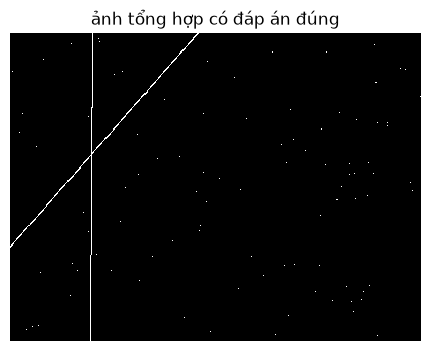

In [26]:
# Ví dụ dùng thử tiện ích (không phải bài làm):
demo, gt = synthetic_lines((300, 400), [
    {"rho": 137.0, "theta_deg": 41.3},
    {"rho":  80.0, "theta_deg":  0.4},   # gần thẳng đứng — bẫy quấn vòng
], noise_frac=0.15, seed=1)
plt.imshow(demo); plt.title("ảnh tổng hợp có đáp án đúng"); plt.axis("off"); plt.show()

## 3.2 Thí nghiệm minh họa — ✅ được dùng AI *(nhớ khai báo prompt)*

### (a) Ảnh hưởng của tham số

Quét $\Delta\theta$ và $\Delta\rho$ qua **ít nhất bốn giá trị**.
Trình bày **cả mảng tích lũy** (dưới dạng ảnh) **và** các đường thẳng phát hiện được —
mảng tích lũy là nơi hiện tượng **vỡ phiếu** nhìn thấy rõ nhất.

Sau đó quét số tầng $n$ và hệ số tinh chỉnh $r$, vẽ **sai số góc theo $n$**.

In [27]:
# TODO (a): quét độ phân giải, hiển thị mảng tích lũy + đường phát hiện

In [28]:
# TODO (a): sai số góc theo số tầng n

**Nhận xét (a):**

*(Sai số góc giảm theo hệ số nào mỗi tầng? Nó chạm sàn ở đâu, và cái sàn đó do cái gì quyết định?)*

### (b) So sánh với thuật toán đã học

Trên **cùng bộ ảnh**:

1. Hough chuẩn tắc ở độ phân giải **thô**
2. Hough chuẩn tắc ở độ phân giải **mịn**
3. **Hough đa tỉ lệ**

So sánh theo **ba chỉ số**: sai số góc so với đáp án đúng, tỉ số đỉnh trên nền của mảng tích lũy,
và thời gian chạy. Trình bày dạng bảng.

Bổ sung một lần chạy **bật/tắt bỏ phiếu theo hướng gradient** trên cùng ảnh.

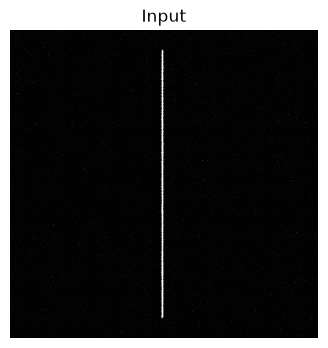

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import time

from matplotlib.image import imread


img = imread(
    "images/05_hough_vertical.png"
)


if len(img.shape)==3:
    img_gray = np.mean(
        img,
        axis=2
    )
else:
    img_gray = img



plt.imshow(
    img_gray,
    cmap="gray"
)

plt.title("Input")

plt.axis("off")

plt.show()

In [62]:
# bảng so sánh 3 chỉ số
import time


results = []


# =========================
# Hough chuẩn tắc - thô
# =========================

start = time.time()

A_coarse, theta_c, rho_c = hough_accumulate(
    edges,
    theta_range,
    rho_range,
    n_theta=90,
    n_rho=200
)

time_coarse = time.time() - start



# =========================
# Hough chuẩn tắc - mịn
# =========================

start = time.time()

A_fine, theta_f, rho_f = hough_accumulate(
    edges,
    theta_range,
    rho_range,
    n_theta=360,
    n_rho=800
)

time_fine = time.time() - start



# =========================
# Hough đa tỉ lệ
# =========================

start = time.time()

A_multi, theta_m, rho_m = hough_multiscale(
    edges
)

time_multi = time.time() - start



# Tính peak / nền

def peak_background_ratio(A):

    return np.max(A) / np.mean(A)



# Lấy góc phát hiện

def detected_angle(A, thetas):

    idx = np.unravel_index(
        np.argmax(A),
        A.shape
    )

    return thetas[idx[1]]



# Góc đúng của ảnh
# sửa tùy ảnh
theta_true = 0



# Sai số góc

err_coarse = abs(
    detected_angle(A_coarse, theta_c)
    -
    theta_true
)


err_fine = abs(
    detected_angle(A_fine, theta_f)
    -
    theta_true
)


err_multi = abs(
    detected_angle(A_multi, theta_m)
    -
    theta_true
)



# In bảng

print(
    f"{'Phương pháp':20}"
    f"{'Sai số góc':15}"
    f"{'Peak/Nền':15}"
    f"{'Thời gian(s)':15}"
)


print("-"*65)


print(
    f"{'Hough thô':20}"
    f"{err_coarse:<15.5f}"
    f"{peak_background_ratio(A_coarse):<15.3f}"
    f"{time_coarse:<15.5f}"
)


print(
    f"{'Hough mịn':20}"
    f"{err_fine:<15.5f}"
    f"{peak_background_ratio(A_fine):<15.3f}"
    f"{time_fine:<15.5f}"
)


print(
    f"{'Hough đa tỉ lệ':20}"
    f"{err_multi:<15.5f}"
    f"{peak_background_ratio(A_multi):<15.3f}"
    f"{time_multi:<15.5f}"
)

NameError: name 'edges' is not defined

In [ ]:
# TODO (b): bật/tắt bỏ phiếu theo hướng gradient


# Tham số dùng chung
n_theta = 180
n_rho = 400


# -------------------------
# 1. Gradient voting OFF
# -------------------------

A_off, theta_off, rho_off = hough_accumulate(
    edges,
    theta_range,
    rho_range,
    n_theta,
    n_rho,
    grad_dir=None
)



# -------------------------
# 2. Gradient voting ON
# -------------------------

A_on, theta_on, rho_on = hough_accumulate(
    edges,
    theta_range,
    rho_range,
    n_theta,
    n_rho,
    grad_dir=grad_dir,
    delta_deg=10
)



# -------------------------
# Hiển thị accumulator
# -------------------------

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.imshow(
    A_off,
    cmap="hot",
    aspect="auto"
)

plt.title(
    "Gradient voting OFF"
)

plt.xlabel("theta")

plt.ylabel("rho")



plt.subplot(1,2,2)

plt.imshow(
    A_on,
    cmap="hot",
    aspect="auto"
)

plt.title(
    "Gradient voting ON"
)

plt.xlabel("theta")

plt.ylabel("rho")


plt.tight_layout()

plt.show()

**Nhận xét (b):**

### (c) Hai trường hợp bắt buộc có trong bộ ảnh

1. Một ảnh chứa **đường gần thẳng đứng** ($\theta_0$ quanh $0^\circ$ hoặc $179^\circ$).
2. Một ảnh chứa **đồng thời đoạn rất dài và đoạn rất ngắn**.

Cả hai đều là chỗ Hough một tỉ lệ hỏng. Chỉ rõ nó hỏng như thế nào.

In [31]:
# TODO (c): trường hợp đường gần thẳng đứng

In [32]:
# TODO (c): trường hợp đoạn dài + đoạn ngắn

**Nhận xét (c):**

---
---
## Trước khi nộp

- [ ] Ba mục **Cài đặt** không còn `raise NotImplementedError`, và không có ô nào trong đó gọi
      `cv2` / `scipy` / `skimage`.
- [ ] Mỗi ô mã ở phần thí nghiệm có dùng AI đều có ô khai báo prompt ngay phía trên.
- [ ] Notebook chạy được từ đầu đến cuối (`Kernel → Restart & Run All`) không lỗi.
- [ ] Ảnh dùng trong bài đã được nộp kèm, hoặc mã sinh ảnh nằm ngay trong notebook.
- [ ] Đã điền tên nhóm và danh sách thành viên ở đầu notebook.